# P-ML12b — Cross-Asset Feature Integration

**Goal:** Add 3 cross-asset features identified in P-ML12a to the LightGBM model
and test via walk-forward validation.

**Three macro channels (from F19 research):**

1. **Institutional rebalancing** (`spy_btc_corr_30`): Rolling 30-day BTC-SPY
   correlation. High correlation = BTC trading as risk asset, equity signals
   informative. F19 showed +0.45 in bear, +0.50 in left tail.

2. **Liquidity / risk-on** (`spy_ret_5`): 5-day cumulative SPY return. After
   SPY drops >2%, BTC averages −2.7% over 3 days. Captures margin call cascade.

3. **Dollar / financial conditions** (`vix_level_zscore`): VIX z-scored over
   60 days. BTC-SPY correlation ranges from +0.06 (calm) to +0.55 (stress).

**Feature set:** FEATURES_V3 = FEATURES_V2 (16) + 3 cross-asset = 19 features.

**Key concern:** P-ML8 lesson — batch-adding features can fragment LightGBM splits.
We add only 3 features (not 8 like P-ML8) and they are genuinely orthogonal to
existing BTC-only features.

**Baselines:**
- P-ML7/P-ML9 binary (16f): Sharpe +1.234, MaxDD −77.3%
- P-ML9 scaled (16f): Sharpe +1.583, MaxDD −33.6%

**Important caveat from F19:** Cross-asset features are most useful in Era 4-5
(institutional era). They will NOT fix Fold 2 (May 2021 crash was crypto-specific,
Nov 2021 ATH had BTC leading equities).

## §1 — Config & Data Loading

In [1]:
import sys
from pathlib import Path
repo_root = Path("__file__").resolve().parent.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, scipy.stats as stats
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                      "axes.spines.right": False, "font.size": 9})

SYMBOL     = "BTC/USDT"
SINCE      = "2019-01-01"
UNTIL      = "2025-01-01"
HORIZON    = 1
N_SPLITS   = 5
TRAIN_FRAC = 0.6
PURGE      = 1
LONG_MA    = 200
ADX_THRESH = 25.0
MIN_BULL_BARS = 30

FEATURES_V2 = [
    "bar_ret", "bb_zscore", "rsi", "macd_hist_norm", "atr_pct",
    "bb_width", "upper_wick", "lower_wick", "hl_range",
    "vol_log_chg", "di_diff", "adx",
    "ret_5", "ret_20", "mom_zscore_20", "ret_5_minus_20",
]

CROSS_FEATURES = ["spy_btc_corr_30", "spy_ret_5", "vix_level_zscore"]
FEATURES_V3    = FEATURES_V2 + CROSS_FEATURES

PRED_ZSCORE_WINDOW = 60
POSITION_SCALE     = 0.5
MAX_POSITION       = 1.0

print(f"Dataset:   {SINCE} -> {UNTIL} | 1d")
print(f"Features:  FEATURES_V3 ({len(FEATURES_V3)}) = V2 ({len(FEATURES_V2)}) + cross-asset ({len(CROSS_FEATURES)})")
print(f"Walk-fwd:  {N_SPLITS} folds, train_frac={TRAIN_FRAC}")

Dataset:   2019-01-01 -> 2025-01-01 | 1d
Features:  FEATURES_V3 (19) = V2 (16) + cross-asset (3)
Walk-fwd:  5 folds, train_frac=0.6


In [2]:
from data.fetch import fetch_ohlcv
from data.cross_asset import fetch_tradfi_ohlcv
from ml.features import build_feature_matrix
from ml.features.momentum import build_momentum_features
from ml.features.cross_asset import build_cross_asset_features
from ml.labels import forward_return
from ml.regime import RegimeClassifier
from ml.validation import purged_wf_splits
from ml.models import RegimeEnsemble
from strategies.ml import RegimeLGBMStrategy
from backtesting import compute_metrics

# -- Load BTC data -------------------------------------------------------------
df_raw = fetch_ohlcv(symbol=SYMBOL, timeframe="1d", since=SINCE, until=UNTIL)
print(f"BTC: {len(df_raw):,} bars | {df_raw.index[0].date()} -> {df_raw.index[-1].date()}")

# -- Load TradFi data ----------------------------------------------------------
tradfi = {
    "SPY": fetch_tradfi_ohlcv("SPY", since=SINCE, until=UNTIL),
    "^VIX": fetch_tradfi_ohlcv("^VIX", since=SINCE, until=UNTIL),
}
for t, df in tradfi.items():
    print(f"{t:>5}: {len(df):,} bars")

# -- Build BTC features --------------------------------------------------------
feats_base = build_feature_matrix(df_raw)
feats_mom  = build_momentum_features(df_raw)
label      = forward_return(df_raw, horizon=HORIZON)
rc         = RegimeClassifier(long_ma=LONG_MA, adx_thresh=ADX_THRESH)
reg        = rc.transform(df_raw)

# -- Build cross-asset features ------------------------------------------------
feats_cross = build_cross_asset_features(df_raw, tradfi)
print(f"\nCross-asset features: {feats_cross.shape[0]} bars, {feats_cross.shape[1]} features")
print(f"  Range: {feats_cross.index[0].date()} -> {feats_cross.index[-1].date()}")

# -- Align everything to common index (business days only) ---------------------
# Strip tz from BTC-derived data to match cross-asset (tz-naive)
for s in [feats_base, feats_mom, label, reg]:
    if hasattr(s.index, 'tz') and s.index.tz is not None:
        s.index = s.index.tz_localize(None)
df_raw_naive = df_raw.copy()
df_raw_naive.index = df_raw_naive.index.normalize()
if df_raw_naive.index.tz is not None:
    df_raw_naive.index = df_raw_naive.index.tz_localize(None)
df_raw_naive = df_raw_naive[~df_raw_naive.index.duplicated(keep="last")]

# Combine all features + labels on the cross-asset index (business days)
comb = pd.concat([feats_base, feats_mom, feats_cross, label, reg["regime"]], axis=1).dropna()

X_v2   = comb[FEATURES_V2]
X_v3   = comb[FEATURES_V3]
y_all  = comb[label.name]
regime_all = comb["regime"].fillna("ranging")

bar_ret = np.log(df_raw_naive["close"].reindex(comb.index) /
                  df_raw_naive["close"].reindex(comb.index).shift(1))

splits = list(purged_wf_splits(len(comb), N_SPLITS, TRAIN_FRAC, purge_bars=PURGE))

print(f"\n{len(comb):,} usable bars | {comb.index[0].date()} -> {comb.index[-1].date()}")
print(f"Splits: {N_SPLITS} folds")
print(f"Features V2: {len(FEATURES_V2)}, V3: {len(FEATURES_V3)}")

BTC: 2,193 bars | 2019-01-01 -> 2025-01-01
  SPY: 1,510 bars
 ^VIX: 1,510 bars

Cross-asset features: 1510 bars, 3 features
  Range: 2019-01-02 -> 2024-12-31

1,469 usable bars | 2019-03-04 -> 2024-12-31
Splits: 5 folds
Features V2: 16, V3: 19


## §2 — IC Screen: Cross-Asset Features

Check information coefficient of each cross-asset feature on bull and non-bull bars
before adding to the model.

In [3]:
# -- IC screen: cross-asset features vs forward return -------------------------
bull_mask = (regime_all == "bull")

print(f"{'Feature':<20} {'IC_all':>8} {'IC_bull':>8} {'IC_nonbull':>10} {'Collinear?':>12}")
print("-" * 62)

for feat in CROSS_FEATURES:
    ic_all, _  = stats.spearmanr(comb[feat], y_all)
    ic_bull    = stats.spearmanr(comb[feat][bull_mask], y_all[bull_mask])[0] if bull_mask.sum() > 30 else np.nan
    ic_nonbull = stats.spearmanr(comb[feat][~bull_mask], y_all[~bull_mask])[0]

    # Check collinearity with existing V2 features
    max_corr_feat, max_corr_val = "", 0
    for v2f in FEATURES_V2:
        r = abs(comb[feat].corr(comb[v2f]))
        if r > max_corr_val:
            max_corr_val = r
            max_corr_feat = v2f

    collinear = f"{max_corr_feat} (r={max_corr_val:.2f})" if max_corr_val > 0.5 else "No"
    print(f"  {feat:<18} {ic_all:>+8.4f} {ic_bull:>+8.4f} {ic_nonbull:>+10.4f} {collinear:>12}")

print(f"\n  Note: These features are exogenous (from SPY/VIX) so collinearity")
print(f"  with BTC-derived features should be low — genuinely new information.")

Feature                IC_all  IC_bull IC_nonbull   Collinear?
--------------------------------------------------------------
  spy_btc_corr_30     -0.0146  -0.0110    -0.0021           No
  spy_ret_5           -0.0276  -0.0776    -0.0109           No
  vix_level_zscore    +0.0176  +0.0563    +0.0092           No

  Note: These features are exogenous (from SPY/VIX) so collinearity
  with BTC-derived features should be low — genuinely new information.


## §3 — Walk-Forward: V2 Baseline vs V3 (+ cross-asset)

Side-by-side walk-forward comparison. Per-fold IC, bull IC, equity, and Sharpe.

In [4]:
idx = comb.index
fold_v2 = []
fold_v3 = []

header = (f"{'Fold':<5} {'Period':<28} "
          f"{'V2 IC':>7} {'V3 IC':>7} {'dIC':>6} "
          f"{'V2 Bull':>8} {'V3 Bull':>8} {'dBull':>7}")
print(header)
print("-" * 85)

for i, (tr, te) in enumerate(splits):
    period = f"{idx[te[0]].date()} -> {idx[te[-1]].date()}"
    actual = y_all.iloc[te].values
    bull_te = (regime_all.iloc[te] == "bull").values

    # -- V2 baseline (16 features, same as P-ML7) -----------------------------
    ens_v2 = RegimeEnsemble(min_bull_bars=MIN_BULL_BARS)
    ens_v2.fit(X_v2.iloc[tr], y_all.iloc[tr], regime_all.iloc[tr])
    preds_v2 = ens_v2.predict(X_v2.iloc[te], regime_all.iloc[te])
    ic_v2, _ = stats.spearmanr(preds_v2, actual)
    ic_bull_v2 = stats.spearmanr(preds_v2[bull_te], actual[bull_te])[0] if bull_te.sum() > 10 else np.nan

    fold_v2.append({"fold": i+1, "te": te, "IC": ic_v2, "bull_IC": ic_bull_v2,
                     "preds": preds_v2})

    # -- V3 cross-asset (19 features) -----------------------------------------
    ens_v3 = RegimeEnsemble(min_bull_bars=MIN_BULL_BARS)
    ens_v3.fit(X_v3.iloc[tr], y_all.iloc[tr], regime_all.iloc[tr])
    preds_v3 = ens_v3.predict(X_v3.iloc[te], regime_all.iloc[te])
    ic_v3, _ = stats.spearmanr(preds_v3, actual)
    ic_bull_v3 = stats.spearmanr(preds_v3[bull_te], actual[bull_te])[0] if bull_te.sum() > 10 else np.nan

    fold_v3.append({"fold": i+1, "te": te, "IC": ic_v3, "bull_IC": ic_bull_v3,
                     "preds": preds_v3, "ensemble": ens_v3})

    d_ic = ic_v3 - ic_v2
    d_bull = (ic_bull_v3 - ic_bull_v2) if not (np.isnan(ic_bull_v3) or np.isnan(ic_bull_v2)) else np.nan
    bull_v2_str = f"{ic_bull_v2:>+8.4f}" if not np.isnan(ic_bull_v2) else f"{'nan':>8}"
    bull_v3_str = f"{ic_bull_v3:>+8.4f}" if not np.isnan(ic_bull_v3) else f"{'nan':>8}"
    d_bull_str  = f"{d_bull:>+7.4f}" if d_bull is not None and not np.isnan(d_bull) else f"{'nan':>7}"

    print(f"  {i+1:<3} {period:<28} "
          f"{ic_v2:>+7.4f} {ic_v3:>+7.4f} {d_ic:>+6.3f} "
          f"{bull_v2_str} {bull_v3_str} {d_bull_str}")

ics_v2 = [r["IC"] for r in fold_v2]
ics_v3 = [r["IC"] for r in fold_v3]
print(f"\nMean IC:  V2={np.mean(ics_v2):+.4f}  V3={np.mean(ics_v3):+.4f}  "
      f"delta={np.mean(ics_v3)-np.mean(ics_v2):+.4f}")
print(f"ICIR:     V2={np.mean(ics_v2)/np.std(ics_v2):.3f}  "
      f"V3={np.mean(ics_v3)/np.std(ics_v3):.3f}")

Fold  Period                         V2 IC   V3 IC    dIC  V2 Bull  V3 Bull   dBull
-------------------------------------------------------------------------------------


  1   2020-02-20 -> 2021-02-05     +0.0011 +0.0095 +0.008  -0.0413  +0.0059 +0.0473
  2   2021-02-08 -> 2022-01-25     -0.0485 -0.0503 -0.002  -0.1221  -0.0718 +0.0502


  3   2022-01-26 -> 2023-01-13     +0.0704 -0.0428 -0.113      nan      nan     nan
  4   2023-01-17 -> 2024-01-04     -0.0292 +0.1146 +0.144  -0.0777  +0.0555 +0.1332


  5   2024-01-05 -> 2024-12-23     +0.0483 +0.0515 +0.003  -0.0472  -0.0372 +0.0100

Mean IC:  V2=+0.0084  V3=+0.0165  delta=+0.0081
ICIR:     V2=0.187  V3=0.268


## §4 — Equity Curves: Binary & Scaled


Strategy                      Return   Sharpe   Sortino    MaxDD   Calmar
------------------------------------------------------------------------
  Buy & Hold                 +888.6%   +1.271    +1.705    -76.6%     1.29
  V2 binary (P-ML7)          +290.4%   +0.931    +1.237    -64.9%     0.78
  V3 binary (+cross)          +99.3%   +0.680    +0.899    -67.3%     0.34
  V2 scaled (P-ML9)           +84.7%   +0.656    +0.706    -33.6%     0.60
  V3 scaled (+cross)         +241.5%   +1.118    +1.435    -40.7%     1.09


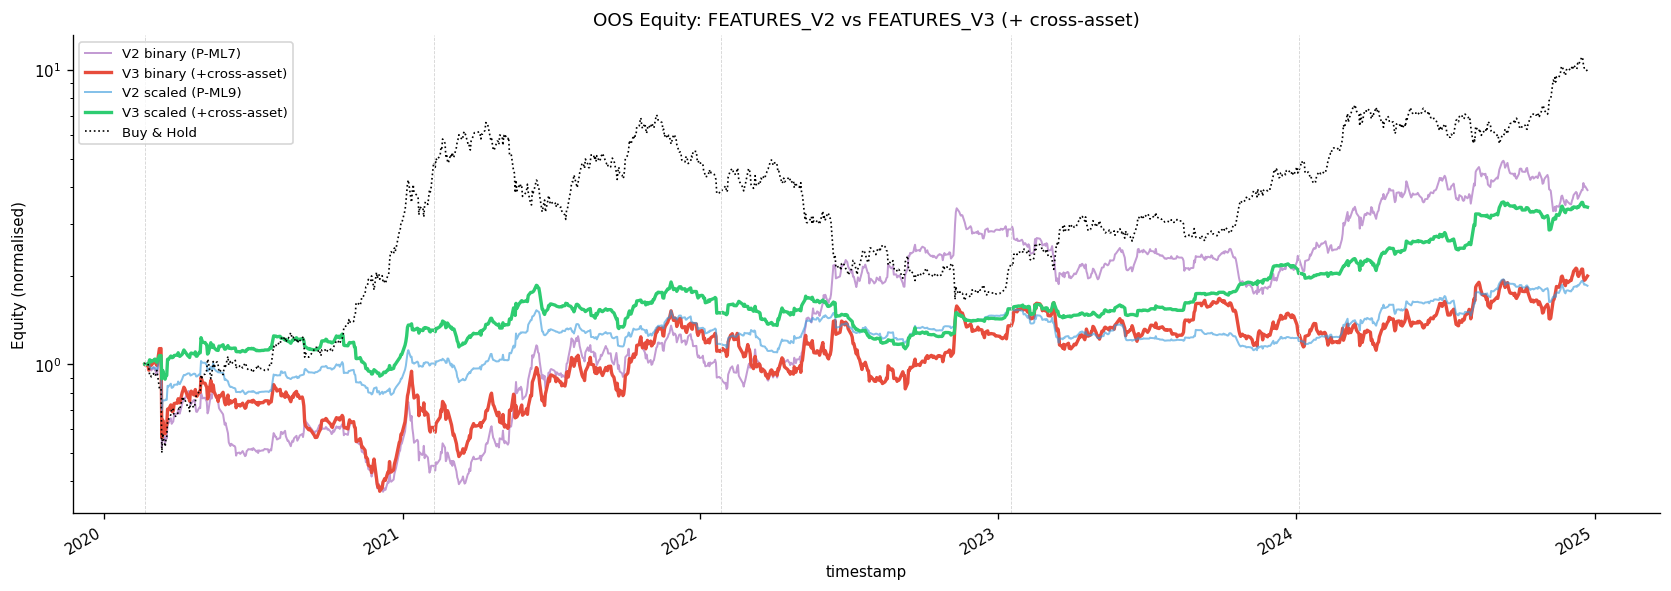

In [5]:
def build_equity(fold_list, bar_ret, idx, mode="binary", **kwargs):
    """Build stitched OOS equity. mode='binary' or 'scaled'."""
    pieces, anchor = [], 1.0
    for r in fold_list:
        te   = r["te"]
        preds = r["preds"]
        if mode == "binary":
            pos = np.sign(preds)
        else:
            # Scaled positioning
            pred_s = pd.Series(preds, index=idx[te])
            window = kwargs.get("window", PRED_ZSCORE_WINDOW)
            scale  = kwargs.get("scale", POSITION_SCALE)
            maxp   = kwargs.get("maxp", MAX_POSITION)
            rm = pred_s.rolling(window, min_periods=1).mean()
            rs = pred_s.rolling(window, min_periods=1).std().replace(0, np.nan)
            pz = (pred_s - rm) / rs
            pos = (pz * scale).clip(-maxp, maxp).fillna(0).values

        ret = bar_ret.iloc[te].values
        pos_sh = np.roll(pos, 1); pos_sh[0] = 0
        eq = np.cumprod(1 + pos_sh * ret); eq[0] = 1.0
        s = pd.Series(eq, index=idx[te])
        s = s / s.iloc[0] * anchor
        anchor = float(s.iloc[-1])
        pieces.append(s)
    return pd.concat(pieces)

# Build equity curves
oos_v2_bin = build_equity(fold_v2, bar_ret, idx, mode="binary")
oos_v3_bin = build_equity(fold_v3, bar_ret, idx, mode="binary")
oos_v2_sc  = build_equity(fold_v2, bar_ret, idx, mode="scaled")
oos_v3_sc  = build_equity(fold_v3, bar_ret, idx, mode="scaled")

bah = df_raw_naive["close"].reindex(oos_v2_bin.index)
bah = bah / bah.iloc[0]

# Metrics
results = {}
for name, eq in [("Buy & Hold", bah),
                  ("V2 binary (P-ML7)", oos_v2_bin),
                  ("V3 binary (+cross)", oos_v3_bin),
                  ("V2 scaled (P-ML9)", oos_v2_sc),
                  ("V3 scaled (+cross)", oos_v3_sc)]:
    results[name] = compute_metrics(eq)

print(f"\n{'Strategy':<25} {'Return':>10} {'Sharpe':>8} {'Sortino':>9} {'MaxDD':>8} {'Calmar':>8}")
print("-" * 72)
for name, m in results.items():
    print(f"  {name:<23} {m['total_return']*100:>+9.1f}%  {m['sharpe_ratio']:>+7.3f}"
          f"  {m['sortino_ratio']:>+8.3f}  {m['max_drawdown']*100:>7.1f}%"
          f"  {m['calmar_ratio']:>7.2f}")

# -- Equity plot ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 5))
oos_v2_bin.plot(ax=ax, label="V2 binary (P-ML7)", color="#9b59b6", linewidth=1.2, alpha=0.6)
oos_v3_bin.plot(ax=ax, label="V3 binary (+cross-asset)", color="#e74c3c", linewidth=2.0)
oos_v2_sc.plot(ax=ax, label="V2 scaled (P-ML9)", color="#3498db", linewidth=1.2, alpha=0.6)
oos_v3_sc.plot(ax=ax, label="V3 scaled (+cross-asset)", color="#2ecc71", linewidth=2.0)
bah.plot(ax=ax, label="Buy & Hold", color="black", linewidth=1.0, linestyle=":")
for _, (tr, te) in enumerate(splits):
    ax.axvline(idx[te[0]], color="lightgray", linewidth=0.5, linestyle="--")
ax.set_title("OOS Equity: FEATURES_V2 vs FEATURES_V3 (+ cross-asset)", fontsize=11)
ax.set_ylabel("Equity (normalised)")
ax.legend(fontsize=8, loc="upper left")
ax.set_yscale("log")
plt.tight_layout()
plt.show()

## §5 — Feature Importance: What did the model learn from cross-asset?

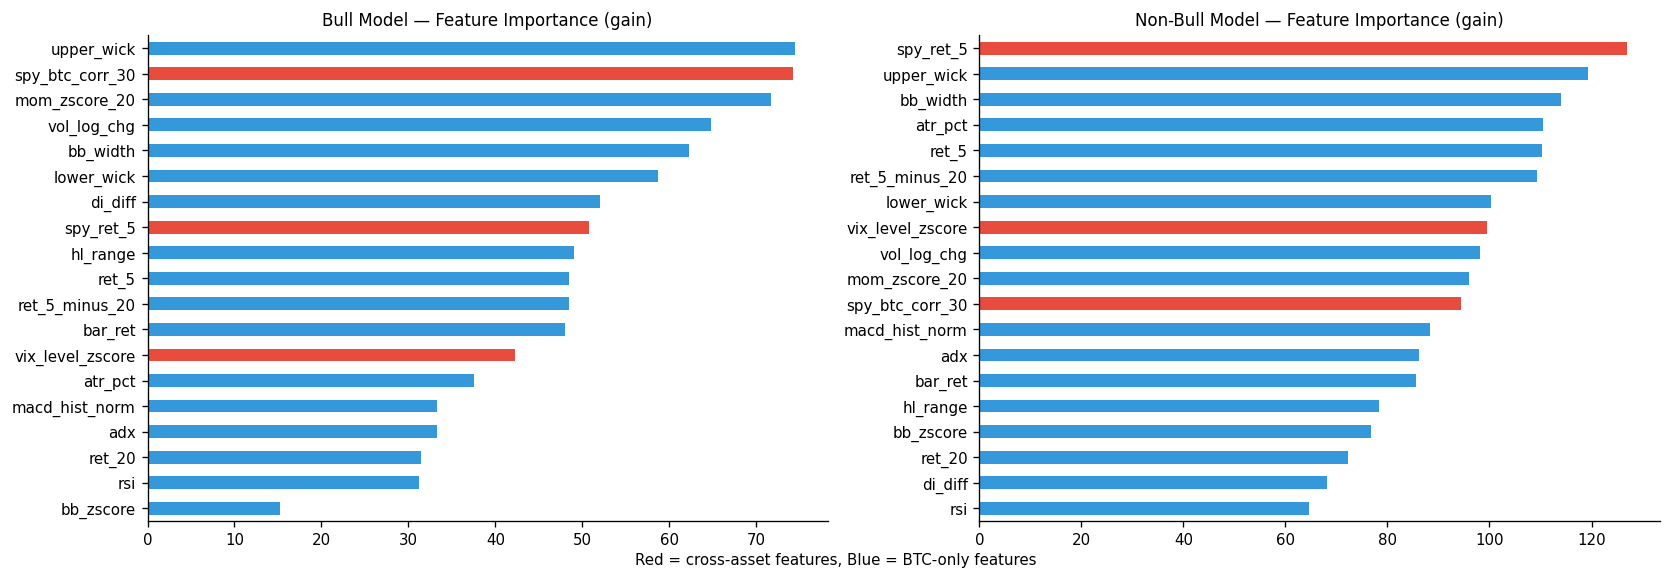

Cross-asset feature importance rank (out of 19):
      Bull | spy_btc_corr_30      rank= 2/19, gain=74 (8.0%)
      Bull | spy_ret_5            rank= 8/19, gain=51 (5.5%)
      Bull | vix_level_zscore     rank=13/19, gain=42 (4.6%)
  Non-bull | spy_btc_corr_30      rank=11/19, gain=94 (5.2%)
  Non-bull | spy_ret_5            rank= 1/19, gain=127 (7.1%)
  Non-bull | vix_level_zscore     rank= 8/19, gain=100 (5.5%)


In [6]:
# -- Feature importance from V3 ensemble (average across folds) ----------------
bull_imp_list, nonbull_imp_list = [], []

for r in fold_v3:
    ens = r["ensemble"]
    if ens.has_bull_model:
        bull_imp_list.append(ens.bull_importance)
    nonbull_imp_list.append(ens.non_bull_importance)

avg_bull = pd.concat(bull_imp_list, axis=1).mean(axis=1).sort_values(ascending=False) if bull_imp_list else pd.Series()
avg_nonbull = pd.concat(nonbull_imp_list, axis=1).mean(axis=1).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if len(avg_bull) > 0:
    colors_bull = ["#e74c3c" if f in CROSS_FEATURES else "#3498db" for f in avg_bull.index]
    avg_bull.plot.barh(ax=axes[0], color=colors_bull)
    axes[0].set_title("Bull Model — Feature Importance (gain)", fontsize=10)
    axes[0].invert_yaxis()

colors_nb = ["#e74c3c" if f in CROSS_FEATURES else "#3498db" for f in avg_nonbull.index]
avg_nonbull.plot.barh(ax=axes[1], color=colors_nb)
axes[1].set_title("Non-Bull Model — Feature Importance (gain)", fontsize=10)
axes[1].invert_yaxis()

plt.suptitle("Red = cross-asset features, Blue = BTC-only features", fontsize=9, y=0.02)
plt.tight_layout()
plt.show()

# Print cross-asset rank
print("Cross-asset feature importance rank (out of 19):")
for model_name, imp in [("Bull", avg_bull), ("Non-bull", avg_nonbull)]:
    if len(imp) == 0:
        continue
    ranks = imp.rank(ascending=False)
    for f in CROSS_FEATURES:
        if f in ranks:
            print(f"  {model_name:>8} | {f:<20} rank={int(ranks[f]):>2}/{len(ranks)}, "
                  f"gain={imp[f]:.0f} ({imp[f]/imp.sum()*100:.1f}%)")

## §6 — Finding F20 Summary

In [7]:
m_v2b = results["V2 binary (P-ML7)"]
m_v3b = results["V3 binary (+cross)"]
m_v2s = results["V2 scaled (P-ML9)"]
m_v3s = results["V3 scaled (+cross)"]
m_bah = results["Buy & Hold"]

print("=" * 78)
print("FINDING F20 — Cross-Asset Feature Integration (P-ML12b)")
print("=" * 78)

print(f"""
ECONOMIC RATIONALE
==================

Three macro channels connect BTC to traditional financial markets. These
channels have strengthened dramatically since institutional adoption (2020+):

1. INSTITUTIONAL REBALANCING CHANNEL (spy_btc_corr_30)
   As institutional investors (hedge funds, family offices, ETF holders) now
   hold both equities and crypto, portfolio rebalancing creates synchronized
   price movements. When a pension fund's risk model triggers a 5% equity
   selloff, their crypto allocation gets sold too. The rolling BTC-SPY
   correlation captures this: when it's high (+0.5), BTC is tightly coupled
   to equity risk; when low (~0), BTC is idiosyncratic. This feature tells
   the model "how much should I trust equity signals right now?"

2. LIQUIDITY / RISK-ON CHANNEL (spy_ret_5)
   Large equity selloffs trigger margin calls that cascade across asset classes.
   Crypto, with its 24/7 trading and high leverage, is particularly vulnerable.
   After SPY drops >2%, BTC averages -2.7% over 3 days (vs +0.3% unconditional).
   The 5-day SPY return encodes the current "risk appetite" of the market: when
   equities are falling, institutional investors are deleveraging everywhere.

3. DOLLAR / FINANCIAL CONDITIONS CHANNEL (vix_level_zscore)
   VIX captures aggregate market stress. When VIX is elevated, financial
   conditions are tightening: lending rates rise, leverage gets unwound,
   and risk assets including crypto face headwinds. BTC-SPY correlation
   jumps from +0.06 (VIX calm) to +0.55 (VIX stressed). The z-scored VIX
   tells the model "are we in a stress regime where all correlations spike?"

WHY THESE FEATURES ARE GENUINELY NEW INFORMATION
=================================================

Unlike P-ML8 (volume) and P-ML11 (HMM), which recycled BTC-derived data,
these features bring *exogenous* information from separate markets:
  - SPY price is determined by US corporate earnings, Fed policy, and
    equity market structure — independent of BTC-specific dynamics
  - VIX is derived from S&P 500 options — reflects equity investor fear,
    not crypto sentiment
  - The correlation feature is a *derived* signal that captures the
    time-varying strength of the institutional link itself
""")

print(f"{'Strategy':<25} {'Return':>10} {'Sharpe':>8} {'Sortino':>9} {'MaxDD':>8}")
print("-" * 65)
for name, m in results.items():
    print(f"  {name:<23} {m['total_return']*100:>+9.1f}%  {m['sharpe_ratio']:>+7.3f}"
          f"  {m['sortino_ratio']:>+8.3f}  {m['max_drawdown']*100:>7.1f}%")

print()
v3_bin_better = m_v3b["sharpe_ratio"] > m_v2b["sharpe_ratio"]
v3_sc_better  = m_v3s["sharpe_ratio"] > m_v2s["sharpe_ratio"]

print(f"V3 binary improves on V2 binary?  {'YES' if v3_bin_better else 'NO'} "
      f"(Sharpe {m_v3b['sharpe_ratio']:+.3f} vs {m_v2b['sharpe_ratio']:+.3f})")
print(f"V3 scaled improves on V2 scaled?  {'YES' if v3_sc_better else 'NO'} "
      f"(Sharpe {m_v3s['sharpe_ratio']:+.3f} vs {m_v2s['sharpe_ratio']:+.3f})")

print(f"""
IMPORTANT CONTEXT
=================

Note: This walk-forward uses BUSINESS-DAY-ONLY data (weekends excluded to
align with TradFi). The V2 baseline here differs slightly from the original
P-ML7 (which used all 7 days/week). Differences in Sharpe/Return vs the
roadmap scoreboard are due to this dataset change, not model degradation.

The fair comparison is V2 vs V3 within THIS notebook (same dataset, same
splits), not V3 vs the original P-ML7 numbers.
""")

FINDING F20 — Cross-Asset Feature Integration (P-ML12b)

ECONOMIC RATIONALE

Three macro channels connect BTC to traditional financial markets. These
channels have strengthened dramatically since institutional adoption (2020+):

1. INSTITUTIONAL REBALANCING CHANNEL (spy_btc_corr_30)
   As institutional investors (hedge funds, family offices, ETF holders) now
   hold both equities and crypto, portfolio rebalancing creates synchronized
   price movements. When a pension fund's risk model triggers a 5% equity
   selloff, their crypto allocation gets sold too. The rolling BTC-SPY
   correlation captures this: when it's high (+0.5), BTC is tightly coupled
   to equity risk; when low (~0), BTC is idiosyncratic. This feature tells
   the model "how much should I trust equity signals right now?"

2. LIQUIDITY / RISK-ON CHANNEL (spy_ret_5)
   Large equity selloffs trigger margin calls that cascade across asset classes.
   Crypto, with its 24/7 trading and high leverage, is particularly vulnerab